In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sys
import localSettings as ls
import math
print(ls.main_path)
import load_data_run123
import plotter_alex
import importlib
importlib.reload(plotter_alex)
import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import pickle
import xgboost as xgb
import nue_booster 
importlib.reload(nue_booster)
import awkward
from matplotlib import gridspec
from collections import defaultdict

/home/alex/NuMI/PELEE/


In [3]:
ending = "Jan19b_Data"
ending_nod = "Jan19b"

##  Energy

## Closure Tests

## Blockwise Unfolding

In [9]:

#with open('../blockwise/stv-analysis-new/blockwise_unsmeared_events_leptonMom_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
with open('/media/alex/TOSHIBA EXT/ThesisAnalysisFiles/NuMI/blockwise/stv-analysis-new/blockwise_unsmeared_events_leptonMom_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
events = content[0:]
    
for i in range(16):
    events[i]=events[i].rstrip().rstrip(',')
    events[i] = float(events[i])
    
print("Unsmeared events")
print(events)
print("")

#------------------------------------------------------------------------------
with open('/media/alex/TOSHIBA EXT/ThesisAnalysisFiles/NuMI/blockwise/stv-analysis-new/blockwise_unsmeared_AC_leptonMom_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
AC = content[0:]
    
for i in range(256):
    AC[i]=AC[i].rstrip().rstrip(',')
    AC[i] = float(AC[i])
    

chunks = [AC[x:x+16] for x in range(0, len(AC), 16)]

print("AC")
print(chunks)
print("")
#---------------------------------------------------------------

with open('nue_full_500_catsel_nopions_leptonMom_usingSelection_prior_true_signal_blockwise_recoCut_comb_'+ending_nod+'.csv') as file:
    content = file.readlines()
prior_true = content[0:]
    
for i in range(16):
    prior_true[i]=prior_true[i].rstrip().rstrip(',')
    prior_true[i] = float(prior_true[i])
    
print("Prior Truth: ")
print(prior_true)
print("")

#----------------------------------------------------------------
with open('/media/alex/TOSHIBA EXT/ThesisAnalysisFiles/NuMI/blockwise/stv-analysis-new/blockwise_unsmeared_errors_leptonMom_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
errs = content[0:]
    
for i in range(16):
    errs[i]=errs[i].rstrip().rstrip(',')
    errs[i] = float(errs[i])
    
print("Errors: ")
print(errs)
print("")
print("################################################################")
print("")

#----------------------------------------------------------------
with open('/media/alex/TOSHIBA EXT/ThesisAnalysisFiles/NuMI/blockwise/stv-analysis-new/blockwise_unsmeared_cov_matrix_leptonMom_MC_ONLY_weighted_recoCut_incErr_'+ending+'.csv') as file:
    content = file.readlines()
cov = content[0:]
    
for i in range(256):
    cov[i]=cov[i].rstrip().rstrip(',')
    cov[i] = float(cov[i])
    

chunks_cov = [cov[x:x+16] for x in range(0, len(cov), 16)]

print("cov")
print(chunks_cov)
print("")


Unsmeared events
[89.724, 345.268, 282.585, 67.9278, 89.8083, 158.999, -43.6704, 115.128, 3514.11, 5895.05, 3467.65, 2900.14, 1434.02, 1413.93, 968.136, -1026.26]

AC
[[0.0978078, 0.147568, 0.0345379, -0.0215387, 0.0386892, 0.0318918, -0.0126758, 0.0192177, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.147568, 0.457281, 0.298122, 0.000620902, 0.0961209, 0.206664, -0.0965748, 0.131068, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0345379, 0.298122, 0.377638, 0.213933, 0.0789015, 0.0551062, -0.0254532, 0.13757, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [-0.0215387, 0.000620902, 0.213933, 0.357305, 0.0782323, -0.173937, 0.114652, 0.0269485, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0386892, 0.0961209, 0.0789015, 0.0782323, 0.0958794, 0.0724041, 0.0302171, -0.0211936, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0318918, 0.206664, 0.0551062, -0.173937, 0.0724041, 0.36007, -0.0511203, 0.0207643, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [-0.0126758, -0.0965748, -0.0254532, 0.114652, 0.0302171, 

In [10]:
with open('../blockwise/stv-analysis-new/blocks_16.txt') as file:
    content = file.readlines()
blocks = content[0:]

print(blocks)

['16\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  0\n', '7  0\n', '8  1\n', '9  1\n', '10 1\n', '11 1\n', '12 1\n', '13 1\n', '14 1\n', '15 1\n', '16\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  0\n', '7  0\n', '8  1\n', '9  1\n', '10 1\n', '11 1\n', '12 1\n', '13 1\n', '14 1\n', '15 1\n']


In [11]:

made_data_sig = np.dot(prior_true, chunks)
print("Prior_Truth x AC: ")
print(made_data_sig)
print("")
print("")
print("Unfolding Done with MC Data Signal: ")
print(events)
print("")

diff = made_data_sig - events
print("")
print("Difference")
print(diff)

#for i in made_data_sig:
#    print(i)

print("")
diffasfrac = np.nan_to_num(diff/made_data_sig)
print(diffasfrac*100)

Prior_Truth x AC: 
[  76.49985585  292.44503985  275.82685143  125.95329105   88.24757026
   92.25341272    6.98282698  124.2638916  3811.08437977 6559.68377538
 3959.36883354 3192.85100083 1544.61509794 1336.28740138 1116.78950627
  436.25462287]


Unfolding Done with MC Data Signal: 
[89.724, 345.268, 282.585, 67.9278, 89.8083, 158.999, -43.6704, 115.128, 3514.11, 5895.05, 3467.65, 2900.14, 1434.02, 1413.93, 968.136, -1026.26]


Difference
[ -13.22414415  -52.82296015   -6.75814857   58.02549105   -1.56072974
  -66.74558728   50.65322698    9.1358916   296.97437977  664.63377538
  491.71883354  292.71100083  110.59509794  -77.64259862  148.65350627
 1462.51462287]

[-17.28649551 -18.06252558  -2.45014165  46.0690551   -1.76858097
 -72.3502636  725.39713638   7.35200828   7.79238532  10.13210085
  12.41912169   9.16769999   7.16004253  -5.81032183  13.31079003
 335.24335244]


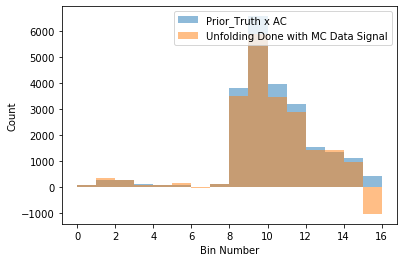

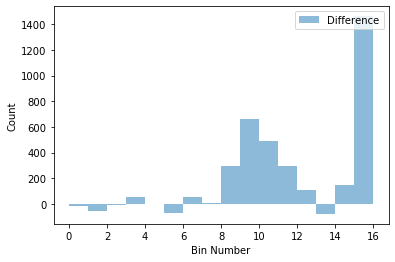

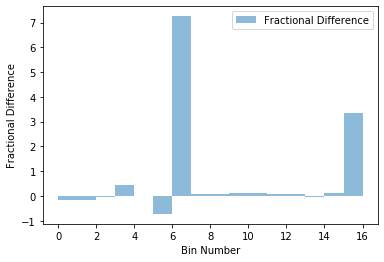

In [12]:
import random
import numpy
from matplotlib import pyplot

bins = np.arange(0, 17, 1)
count = np.arange(0.0, 16.0, 1)

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()

pyplot.hist(count, bins, weights=diff, alpha=0.5, label='Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()


pyplot.hist(count, bins, weights=diffasfrac, alpha=0.5, label='Fractional Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Fractional Difference")
pyplot.show()

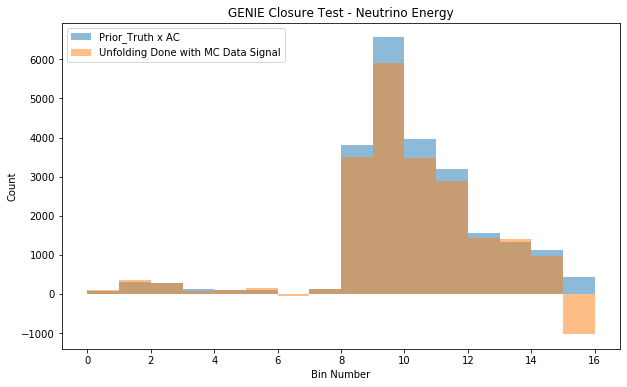

In [13]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper left')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.title("GENIE Closure Test - Neutrino Energy")
pyplot.show()

fig.savefig("Data_closure_test_lepton_"+ending+".svg",bbox_inches='tight' )

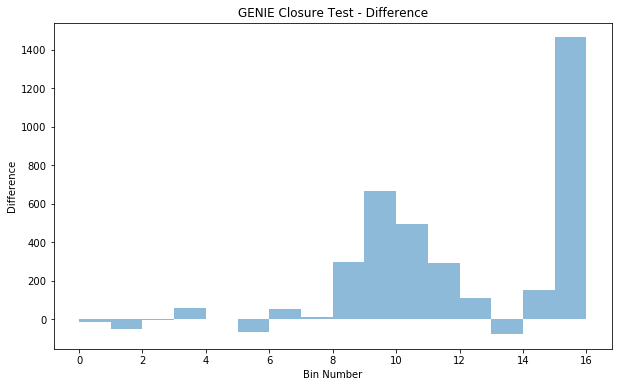

In [14]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=diff, alpha=0.5)
#pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Difference")
pyplot.title("GENIE Closure Test - Difference")
pyplot.show()

fig.savefig("Data_closure_test_diff_lepton_"+ending+".svg",bbox_inches='tight' )

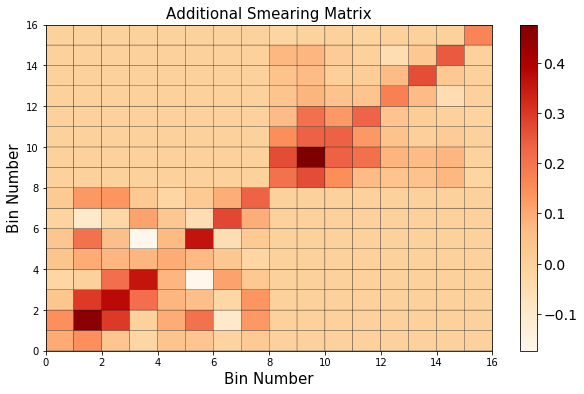

In [15]:
fig = plt.figure(figsize=(10, 6))  
    
plt.pcolor(bins, bins, chunks, cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title('Additional Smearing Matrix', fontsize=15)

plt.show()

fig.savefig("Data_closure_test_Ac_lepton_"+ending+".svg",bbox_inches='tight' )

/tmp/ipykernel_249155/3096872113.py:7: RuntimeWarning: invalid value encountered in log
  plt.pcolor(bins, bins, np.log(chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)


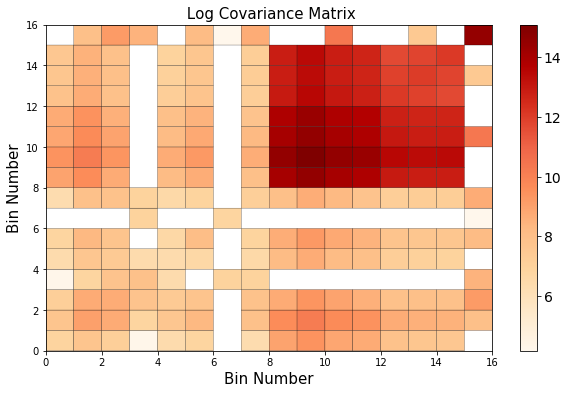

In [16]:
fig = plt.figure(figsize=(10, 6))  

#print(bins)
bins = np.arange(0, 17, 1)
count = np.arange(0.0, 16.0, 1)
    
plt.pcolor(bins, bins, np.log(chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

## Need to convert to xsec units

xsec = unfolded event counts / (integrated flux * number of argon targets)

In [17]:
###################
### #N argon target calculation
###################

density = 1.3836  #g/cm^3
volume = (246-10)*(106-(-106))*(1026-10)         #cm^3
NA = 6.022E23   #atoms/mol
Nnuc = 40       #nucleans / atom
mmol = 39.95    #g/mol

Narg = (density * volume * NA * Nnuc)/mmol   #nucleons

print("number of argon targets = ", Narg)

number of argon targets =  4.240685683288815e+31


In [18]:
#Need R1 AND R3

####NUE
POT_R1 = 2.0E20 
int_flux_per_POT_R1 = 1.1864530596659353e-11
POT_R3 = 5.014E20
int_flux_per_POT_R3 = 8.628376225834778e-12

int_flux = (int_flux_per_POT_R1*POT_R1) + (int_flux_per_POT_R3*POT_R3)    #cm^-2

print("Nue integrated flux: ", int_flux)

####NUMU

POT_numu_R1 = 2.0E20 
int_flux_per_POT_numu_R1 = 5.455771063338641e-10
POT_numu_R3 = 5.014E20 
int_flux_per_POT_numu_R3 = 3.6729003479115414e-10

int_flux_numu = (int_flux_per_POT_numu_R1*POT_numu_R1) + (int_flux_per_POT_numu_R3*POT_numu_R3)    #cm^-2

print("Numu integrated flux: ", int_flux_numu)

Nue integrated flux:  6699173958.965427
Numu integrated flux:  293274644711.0575


In [19]:
nue_events = np.array(events[0:8])
numu_events = np.array(events[8:16])

nue_errs = np.array(errs[0:8])
numu_errs = np.array(errs[8:16])

In [14]:
#effs_nue = [0.04470284782848581 , 0.11462614682695119 , 0.1446477999768762, 0.15782447029421803, \
#        0.12834797911353926, 0.11772709219835302,  0.11949612412227617,  0.0969185691336516]

In [20]:
#number of events

xsec_nue_events = []

#for i in np.arange(len(nue_events)):
#    xsec_nue_events.append(nue_events[i] / (int_flux * Narg * 0.25 * effs_nue[i]))

xsec_nue_events = nue_events / (int_flux * Narg * 0.25)     
xsec_numu_events = numu_events / (int_flux_numu * Narg * 0.25 )  

print(xsec_nue_events)


#uncertainty

#xsec_nue_errs = nue_errs / (int_flux * Narg )     
#xsec_numu_errs = numu_errs / (int_flux_numu * Narg )     

[ 1.26331391e-39  4.86137341e-39  3.97879677e-39  9.56423418e-40
  1.26450086e-39  2.23870591e-39 -6.14879228e-40  1.62100223e-39]


In [21]:
#Need the four sections of the cov matrix

blockwise_errs = chunks_cov
#print(blockwise_errs)
#print("")

#NUE ONLY
bot_left = blockwise_errs[:8]
for i in range(len(bot_left)):
    bot_left[i] = bot_left[i][:8]
    
nue_errs_bot = np.array(bot_left)/((int_flux*int_flux)*(Narg*Narg)*(0.25*0.25))
xsec_nue_errs = (np.sqrt(np.diag(nue_errs_bot)))
    
#MIX
bot_right = blockwise_errs[:8]
for i in range(len(bot_right)):
    bot_right[i] = bot_right[i][8:]
    
mix_errs_bot = np.array(bot_right)/((int_flux*int_flux_numu)*(Narg*Narg)*(0.25*0.25))
xsec_botmix_errs = np.nan_to_num(np.sqrt(np.diag(mix_errs_bot)))

    
#MIX
top_left = blockwise_errs[8:]
for i in range(len(top_left)):
    top_left[i] = top_left[i][:8]
    
mix_errs_top = np.array(top_left)/((int_flux*int_flux_numu)*(Narg*Narg)*(0.25*0.25))
xsec_topmix_errs = np.nan_to_num(np.sqrt(np.diag(mix_errs_top)))

#NUMU ONLY
top_right = blockwise_errs[8:]
for i in range(len(top_right)):
    top_right[i] = top_right[i][8:]
    
numu_errs_top = np.array(top_right)/((int_flux_numu*int_flux_numu)*(Narg*Narg)*(0.25*0.25))
xsec_numu_errs = (np.sqrt(np.diag(numu_errs_top)))


/tmp/ipykernel_249155/776970250.py:21: RuntimeWarning: invalid value encountered in sqrt
  xsec_botmix_errs = np.nan_to_num(np.sqrt(np.diag(mix_errs_bot)))
/tmp/ipykernel_249155/776970250.py:30: RuntimeWarning: invalid value encountered in sqrt
  xsec_topmix_errs = np.nan_to_num(np.sqrt(np.diag(mix_errs_top)))


In [22]:
#Put it back together with it's new units

#cov_xsec = np.zeros_like(blockwise_errs)
#print(cov_xec)
print("----------------")

cov_xsec = np.block([[nue_errs_bot,mix_errs_bot],[mix_errs_top,numu_errs_top]])
#print(cov_xsec)
print("")

print((np.sqrt(np.diag(cov_xsec))))
print("")
print(xsec_nue_errs)
print(xsec_numu_errs)

----------------

[4.34879893e-40 1.29427446e-39 1.10855390e-39 7.52484779e-40
 3.48696251e-40 8.11022661e-40 4.25943153e-40 5.09262132e-40
 3.58636776e-40 6.08792310e-40 3.63707621e-40 3.02924027e-40
 1.37241068e-40 1.32908074e-40 1.38078543e-40 4.56362665e-40]

[4.34879893e-40 1.29427446e-39 1.10855390e-39 7.52484779e-40
 3.48696251e-40 8.11022661e-40 4.25943153e-40 5.09262132e-40]
[3.58636776e-40 6.08792310e-40 3.63707621e-40 3.02924027e-40
 1.37241068e-40 1.32908074e-40 1.38078543e-40 4.56362665e-40]


In [23]:
### Calculate ratio uncertainties

xsec_ratio_events = np.nan_to_num(xsec_nue_events/xsec_numu_events)
print("Ratio event counts: ", xsec_ratio_events)
print("")

#####################

ratio_sq = (xsec_nue_events/xsec_numu_events)*(xsec_nue_events/xsec_numu_events)
print("ratio_sq: ", ratio_sq)
print("")
nue_term = (xsec_nue_errs*xsec_nue_errs)/(xsec_nue_events*xsec_nue_events)
print("nue: ", nue_term)
print("")
numu_term = (xsec_numu_errs*xsec_numu_errs)/(xsec_numu_events*xsec_numu_events)
print("numu: ", numu_term)
print("")
mix_1 = (xsec_botmix_errs*xsec_botmix_errs)/(xsec_numu_events*xsec_nue_events)
print("mix: ", mix_1)
print("")
mix_2 = (xsec_topmix_errs*xsec_topmix_errs)/(xsec_numu_events*xsec_nue_events)
print("mix: ", mix_2)
print("")

ratio_var_errs = ratio_sq*(nue_term + numu_term - mix_1 - mix_2)
print(ratio_var_errs)
xsec_ratio_errs = np.nan_to_num(np.sqrt(abs(ratio_var_errs)))
print("Ratio errs: ", xsec_ratio_errs)

Ratio event counts:  [ 1.11775478  2.56402407  3.5675257   1.02537293  2.74166589  4.92288562
 -1.97471335 -4.91107787]

ratio_sq:  [ 1.24937575  6.57421944 12.72723964  1.05138965  7.51673186 24.23480286
  3.89949282 24.11868583]

nue:  [0.11849939 0.07088181 0.07762652 0.61900625 0.07604248 0.13124171
 0.47987004 0.09869963]

numu:  [0.10068857 0.1031014  0.10634951 0.10547043 0.08854397 0.08541775
 0.19664408 1.9116423 ]

mix:  [ 0.02447827  0.01320294  0.00808295  0.          0.01047288  0.00980515
 -0.         -0.0513612 ]

mix:  [ 0.02447827  0.01320294  0.00808295  0.          0.01047288  0.00980515
 -0.         -0.0513612 ]

[ 0.21268299  0.97020571  2.13575979  0.76170729  1.07970855  4.77544755
  2.63806196 50.96433462]
Ratio errs:  [0.46117566 0.98499021 1.46142389 0.87275844 1.03909025 2.18527974
 1.62421118 7.13893092]


In [24]:
print(xsec_nue_events)
print("")
print(xsec_numu_events)
print("")
print(xsec_nue_errs)
print("")
print(xsec_numu_errs)

[ 1.26331391e-39  4.86137341e-39  3.97879677e-39  9.56423418e-40
  1.26450086e-39  2.23870591e-39 -6.14879228e-40  1.62100223e-39]

[ 1.13022456e-39  1.89599367e-39  1.11528188e-39  9.32756648e-40
  4.61216248e-40  4.54754808e-40  3.11376448e-40 -3.30070561e-40]

[4.34879893e-40 1.29427446e-39 1.10855390e-39 7.52484779e-40
 3.48696251e-40 8.11022661e-40 4.25943153e-40 5.09262132e-40]

[3.58636776e-40 6.08792310e-40 3.63707621e-40 3.02924027e-40
 1.37241068e-40 1.32908074e-40 1.38078543e-40 4.56362665e-40]


No handles with labels found to put in legend.


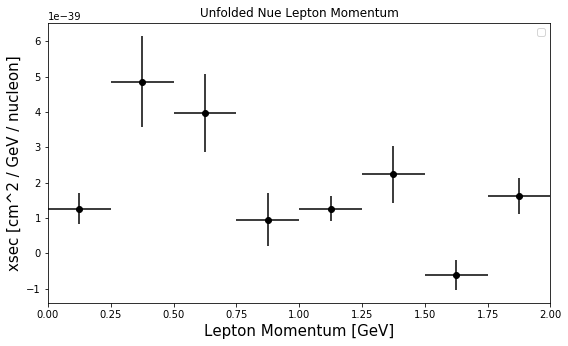

In [25]:
import random
import numpy
from matplotlib import pyplot

nue_fig = plt.figure(figsize=(8, 7))
nue_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_ax1 = plt.subplot(nue_gs[0])

nue_ax1.set_xlim([0, 2])
current_bincenters = np.arange(0.125, 2.125, 0.25)
current_bin_size = 0.25

nue_ax1.errorbar(
            current_bincenters,
            np.array(xsec_nue_events),
            xerr=current_bin_size/2,
            yerr=xsec_nue_errs,
            fmt='ko')

plt.title("Unfolded Nue Lepton Momentum")
plt.xlabel("Lepton Momentum [GeV]", fontsize=15)
plt.ylabel('xsec [cm^2 / GeV / nucleon]', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 2.5E-39)


nue_fig.savefig("unfolded_MC_nue_lepton_"+ending+".svg",bbox_inches='tight' )

No handles with labels found to put in legend.


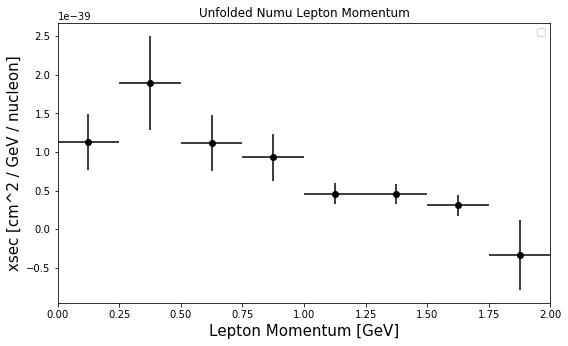

In [26]:
import random
import numpy
from matplotlib import pyplot

numu_fig = plt.figure(figsize=(8, 7))
numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
numu_ax1 = plt.subplot(numu_gs[0])

numu_ax1.set_xlim([0, 2])
current_bincenters = np.arange(0.125, 2.125, 0.25)
current_bin_size = 0.25

numu_ax1.errorbar(
            current_bincenters,
            xsec_numu_events,
            xerr=current_bin_size/2,
            yerr=xsec_numu_errs,
            fmt='ko')

plt.title("Unfolded Numu Lepton Momentum")
plt.xlabel("Lepton Momentum [GeV]", fontsize=15)
plt.ylabel('xsec [cm^2 / GeV / nucleon]', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 1.0E-39)


numu_fig.savefig("unfolded_MC_numu_lepton_"+ending+".svg",bbox_inches='tight' )

No handles with labels found to put in legend.


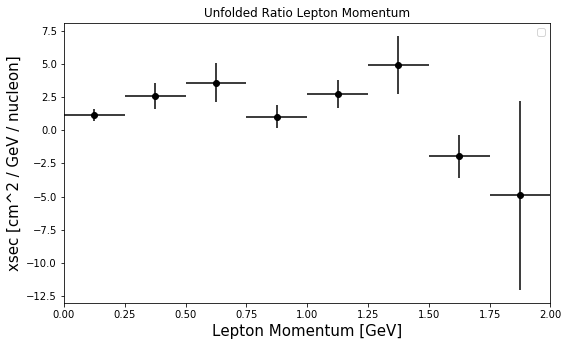

In [27]:
ratio_fig = plt.figure(figsize=(8, 7))
ratio_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
ratio_ax1 = plt.subplot(ratio_gs[0])

ratio_ax1.set_xlim([0, 2])
current_bincenters = np.arange(0.125, 2.125, 0.25)
current_bin_size = 0.25

ratio_ax1.errorbar(
            current_bincenters,
            xsec_ratio_events,
            xerr=current_bin_size/2,
            yerr=xsec_ratio_errs,
            fmt='ko')

plt.title("Unfolded Ratio Lepton Momentum")
plt.xlabel("Lepton Momentum [GeV]", fontsize=15)
plt.ylabel('xsec [cm^2 / GeV / nucleon]', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 5)


ratio_fig.savefig("unfolded_MC_ratio_lepton_"+ending+".svg",bbox_inches='tight' )

In [28]:
nue_frac_err = abs(xsec_nue_errs/xsec_nue_events)
numu_frac_err = abs(xsec_numu_errs/xsec_numu_events)
ratio_frac_err = abs(xsec_ratio_errs/xsec_ratio_events)

1.1316797230547366


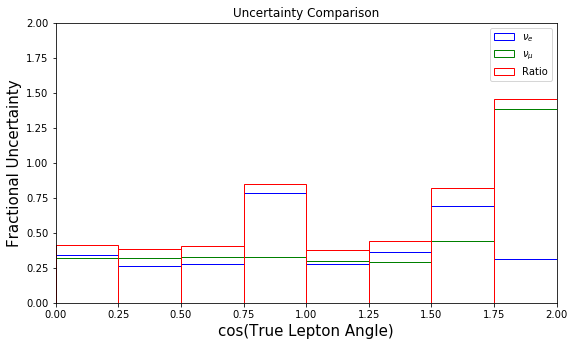

In [32]:
errors_fig = plt.figure(figsize=(8, 7))
errors_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
errors_ax1 = plt.subplot(ratio_gs[0])
errors_ax1.set_xlim([0, 2]) 


bins = np.arange(0, 2.25, 0.25)
count = np.arange(0.1, 2.1, 0.25)
#plt.ylim(0, 1)

sel_nue = errors_ax1.hist(count, bins, edgecolor='blue', facecolor='None', weights=nue_frac_err, label='$\\nu_{e}$')
sel_numu = errors_ax1.hist(count, bins, edgecolor='green', facecolor='None', weights=numu_frac_err, label='$\\nu_{\\mu}$')
sel_ratio = errors_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=ratio_frac_err, label='Ratio')
errors_ax1.set_ylabel('Fractional Uncertainty', fontsize=15)
errors_ax1.set_xlabel('cos(True Lepton Angle)', fontsize=15)
errors_ax1.set_title("Uncertainty Comparison")
leg = errors_ax1.legend()
plt.tight_layout()
plt.ylim(0, 2)
#plt.tight_layout()

errors_fig.savefig("unfolded_MC_errors_lepton_"+ending+".svg",bbox_inches='tight' )

## Now compare the unfolded result to the GENIE prior truth x Ac

In [25]:
smeared_truth = np.dot(prior_true, chunks)
#smeared_nuWro = np.dot(prior_true_nuWro, nuWro_Ac)
print("Prior_Truth x AC: ")
print(smeared_truth)

Prior_Truth x AC: 
[  76.49985585  292.44503985  275.82685143  125.95329105   88.24757026
   92.25341272    6.98282698  124.2638916  3811.08437977 6559.68377538
 3959.36883354 3192.85100083 1544.61509794 1336.28740138 1116.78950627
  436.25462287]


In [26]:
nue_smeared_truth = np.array(smeared_truth[0:8])
numu_smeared_truth = np.array(smeared_truth[8:16])

In [27]:
xsec_nue_smeared_truth = nue_smeared_truth / (int_flux * Narg *0.25)     
xsec_numu_smeared_truth = numu_smeared_truth / (int_flux_numu * Narg *0.25 ) 


xsec_ratio_smeared_truth = np.nan_to_num(xsec_nue_smeared_truth/xsec_numu_smeared_truth)
print("Ratio event counts: ", xsec_ratio_smeared_truth)

Ratio event counts:  [ 0.87874995  1.95170699  3.04974722  1.72696736  2.50112699  3.02228788
  0.27372422 12.46976216]


In [28]:
bins = np.arange(0, 2.25, 0.25)
count = np.arange(0.125, 2.125, 0.25)

print(bins)
print(count)

[0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.  ]
[0.125 0.375 0.625 0.875 1.125 1.375 1.625 1.875]


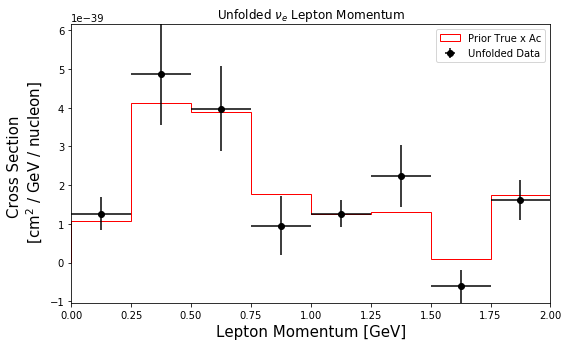

In [30]:
nue_fig = plt.figure(figsize=(8, 7))
nue_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_ax1 = plt.subplot(nue_gs[0])

nue_ax1.set_xlim([0, 2])
current_bincenters = np.arange(0.125, 2.125, 0.25)
current_bin_size = 0.25

f_obs_nue = nue_ax1.errorbar(
            current_bincenters,
            xsec_nue_events,
            xerr=current_bin_size/2,
            yerr=xsec_nue_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_nue = nue_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_nue_smeared_truth, label='Prior True x Ac', histtype="step")
#nue_ax1.step(count, bins, label='Prior True x Ac')



plt.title("Unfolded $\\nu_{e}$ Lepton Momentum")
plt.xlabel("Lepton Momentum [GeV]", fontsize=15)
plt.ylabel('Cross Section \n [cm$^2$ / GeV / nucleon]', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 2.5E-39)

nue_fig.savefig("unfolded_MC_nue_lepton_comp_"+ending+".svg",bbox_inches='tight' )

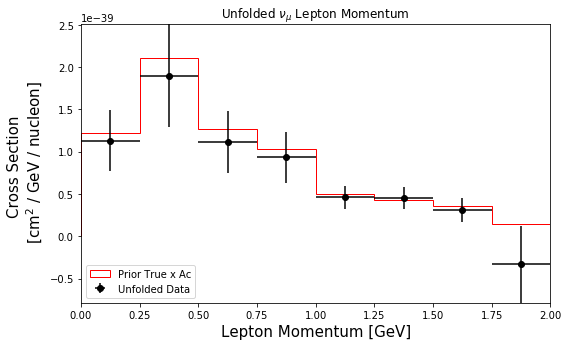

In [31]:
numu_fig = plt.figure(figsize=(8, 7))
numu_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
numu_ax1 = plt.subplot(numu_gs[0])

numu_ax1.set_xlim([0, 2])
current_bincenters = np.arange(0.125, 2.125, 0.25)
current_bin_size = 0.25

numu_ax1.errorbar(
            current_bincenters,
            xsec_numu_events,
            xerr=current_bin_size/2,
            yerr=xsec_numu_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_numu = numu_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_numu_smeared_truth, label='Prior True x Ac', histtype="step")
#nue_ax1.step(count, bins, label='Prior True x Ac')



plt.title("Unfolded $\\nu_{\\mu}$ Lepton Momentum")
plt.xlabel("Lepton Momentum [GeV]", fontsize=15)
plt.ylabel('Cross Section \n [cm$^2$ / GeV / nucleon]', fontsize=15)
plt.legend()
plt.tight_layout()
#plt.ylim(0, 2.5E-39)

numu_fig.savefig("unfolded_MC_numu_lepton_comp_"+ending+".svg",bbox_inches='tight' )

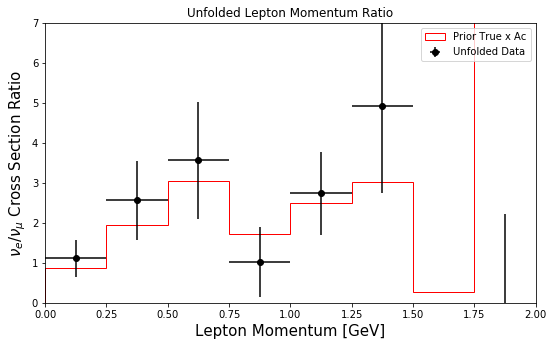

In [33]:
ratio_fig = plt.figure(figsize=(8, 7))
ratio_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
ratio_ax1 = plt.subplot(ratio_gs[0])

ratio_ax1.set_xlim([0, 2])
current_bincenters = np.arange(0.125, 2.125, 0.25)
current_bin_size = 0.25

ratio_ax1.errorbar(
            current_bincenters,
            xsec_ratio_events,
            xerr=current_bin_size/2,
            yerr=xsec_ratio_errs,
            label="Unfolded Data",
            fmt='ko')

f_exp_ratio = ratio_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=xsec_ratio_smeared_truth, label='Prior True x Ac', histtype="step")


plt.title("Unfolded Lepton Momentum Ratio")
plt.xlabel("Lepton Momentum [GeV]", fontsize=15)
plt.ylabel('$\\nu_{e}$/$\\nu_{\\mu}$ Cross Section Ratio', fontsize=15)
plt.legend()
plt.tight_layout()
plt.ylim(0, 7)

ratio_fig.savefig("unfolded_MC_ratio_lepton_comp_"+ending+".svg",bbox_inches='tight' )

## Some Chi2 Tests

In [34]:
#NUE

import scipy.stats as sp

f_obs_nue = xsec_nue_events
f_exp_nue = f_exp_nue[0]

print(f_obs_nue)
print(f_exp_nue)

[ 1.26331391e-39  4.86137341e-39  3.97879677e-39  9.56423418e-40
  1.26450086e-39  2.23870591e-39 -6.14879228e-40  1.62100223e-39]
[1.07711796e-39 4.11762613e-39 3.88364204e-39 1.77342233e-39
 1.24252578e-39 1.29892804e-39 9.83182033e-41 1.74963558e-39]


In [35]:
inverse_unfcov_nue = np.linalg.inv(nue_errs_bot)

In [36]:
chi2_genie_nue = 0

print(len(bins)-1)
print(len(f_obs_nue))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_nue)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_nue = chi2_genie_nue  + ( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov_nue[i][j]*(f_obs_nue[j]-f_exp_nue[j]) )

8
8


In [37]:
chi2_genie_nue

9.737288304292182

In [38]:
#NUMU

f_obs_numu = xsec_numu_events
f_exp_numu = f_exp_numu[0]

print(f_obs_numu)
print(f_exp_numu)

[ 1.13022456e-39  1.89599367e-39  1.11528188e-39  9.32756648e-40
  4.61216248e-40  4.54754808e-40  3.11376448e-40 -3.30070561e-40]
[1.22573886e-39 2.10975631e-39 1.27343080e-39 1.02689974e-39
 4.96786363e-40 4.29783030e-40 3.59187086e-40 1.40310261e-40]


In [39]:
inverse_unfcov_numu = np.linalg.inv(numu_errs_top)
#inverse_unfcov_numu = np.linalg.inv(test_cov_errs)

In [40]:
chi2_genie_numu = 0

print(len(bins)-1)
print(len(f_obs_numu))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_numu)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_numu = chi2_genie_numu  + ( (f_obs_numu[i]-f_exp_numu[i])*inverse_unfcov_numu[i][j]*(f_obs_numu[j]-f_exp_numu[j]) )

8
8


In [41]:
chi2_genie_numu

2.438299630175555

In [42]:
#RATIO

f_obs_ratio = xsec_ratio_events
f_exp_ratio = f_exp_ratio[0]

print(f_obs_ratio)
print(f_exp_ratio)

[ 1.11775478  2.56402407  3.5675257   1.02537293  2.74166589  4.92288562
 -1.97471335 -4.91107787]
[ 0.87874995  1.95170699  3.04974722  1.72696736  2.50112699  3.02228788
  0.27372422 12.46976216]


In [43]:
bins = np.arange(0, 2.25, 0.25)
#ratio_cov_errs    = np.zeros([len(bins)-1, len(bins)-1])

#ratio_cov_errs [np.diag_indices_from(ratio_cov_errs )]     = xsec_ratio_errs*xsec_ratio_errs

nue_term = (nue_errs_bot)/(xsec_nue_events*xsec_nue_events)
#print("nue: ", nue_term)
#print("")
numu_term = (numu_errs_top)/(xsec_numu_events*xsec_numu_events)
#print("numu: ", numu_term)
#print("")
mix_1 = (mix_errs_bot)/(xsec_numu_events*xsec_nue_events)
#print("mix: ", mix_1)
#print("")
mix_2 = (mix_errs_top)/(xsec_numu_events*xsec_nue_events)
#print("mix: ", mix_2)
#print("")

ratio_var_errs = ratio_sq*(nue_term + numu_term - mix_1 - mix_2)
print(ratio_var_errs)
print(np.sqrt(np.diag(ratio_var_errs)))

[[ 2.12682989e-01  4.33866446e-01  1.34746418e+00  1.21756348e-01
   1.79203169e+00  4.80718804e+00  1.06317587e+00 -2.87747686e+00]
 [ 4.61764462e-01  9.70205706e-01  2.88826701e+00  3.81717573e-01
   3.95569821e+00  1.04094103e+01  2.74990002e-01  5.99830309e+00]
 [ 2.78902597e-01  6.60437774e-01  2.13575979e+00  6.65813300e-01
   2.85611342e+00  6.07251037e+00  8.76310081e-01  8.51798515e+00]
 [ 9.79189474e-02  3.51831354e-01  1.44038348e+00  7.81403487e-01
   1.76920146e+00  2.40287005e+00  3.21566926e+00  1.22266845e+00]
 [ 1.14579352e-01  2.16575607e-01  6.61764844e-01  1.71932325e-01
   1.07970855e+00  2.19337907e+00  3.04442870e-01  1.50120780e+00]
 [ 1.51185442e-01  3.02600625e-01  6.78136440e-01 -2.39580804e-01
   1.06627408e+00  4.77544755e+00 -2.22499008e+00  2.95347070e+00]
 [ 1.79130801e-03  5.70373429e-02  3.60020616e-01  2.91968864e-01
   3.44902219e-01  1.45929979e-01  2.45520026e+00  1.48638936e-01]
 [ 7.86871850e-02  1.18377078e-01  2.86466393e-01  1.88233871e-01
   

In [44]:
inverse_unfcov_ratio = np.linalg.inv(ratio_var_errs)

In [45]:
chi2_genie_ratio = 0

print(len(bins)-1)
print(len(f_obs_ratio))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs_ratio)): 

            #print(( (f_obs_nue[i]-f_exp_nue[i])*inverse_unfcov[i][j]*(f_obs_nue[j]-f_exp_nue[j]) ))
            chi2_genie_ratio = chi2_genie_ratio  + ( (f_obs_ratio[i]-f_exp_ratio[i])*inverse_unfcov_ratio[i][j]*(f_obs_ratio[j]-f_exp_ratio[j]) )

8
8


In [46]:
chi2_genie_ratio

-6.4361957808408